## **1: Project Title:** Aerial Object Classification and Detection using Deep Learning

## **1.2: Project Type:**

     - Deep Learning / Computer Vision Project  
      (Binary Image Classification + Object Detection)

- **Contribution – Individual**

- **Name - Dharminder Singh Virk**


## **1.2: Project Summary**

This project focuses on building an intelligent system that can classify aerial images as either Bird or Drone using deep learning techniques. The system also includes an optional object detection module to identify and locate these objects in images using YOLOv8.

A custom Convolutional Neural Network (CNN) model and transfer learning models such as MobileNetV2 are used for classification. The project also applies data preprocessing, augmentation, and performance evaluation techniques to improve model accuracy.

Finally, the trained model is deployed using Streamlit to create an interactive web application where users can upload images and get predictions in real time.

## **1.3: Domain:**
- Aerial Surveillance
- Wildlife Monitoring
- Security & Defense
- Environmental Research

## **1.4: Github Link:** https://github.com/dharmindersinghvirk25-creator/Aerial-Object-Classification-and-Detection-using-Deep-Learning

## **1.5: Skills & Technologies Used**

🔹 **Technical Skills:**
- Deep Learning
- Computer Vision
- Image Classification
- Object Detection
- Model Evaluation

🔹 **Tools & Technologies:**
- Python
- TensorFlow / Keras
- YOLOv8 (Ultralytics)
- OpenCV
- NumPy, Matplotlib
- Scikit-learn
- Streamlit

## **1.5: Data Description**

The project uses two datasets:

🔹 **1. Classification Dataset**
- Type: Image Classification (Binary)
- Classes: Bird, Drone
- Format: JPG images

**Dataset Structure:**

- Train Set:
   Bird: 1414 images
   Drone: 1248 images
- Validation Set:
   Bird: 217 images
   Drone: 225 images
- Test Set:
   Bird: 121 images
   Drone: 94 images  

🔹 **2. Object Detection Dataset (YOLOv8 Format)**
- Total Images: 3319
- Format: Images + .txt annotation files

**Annotation Format:**

<class_id> <x_center> <y_center> <width> <height>

**Data Split:**

- Train: 2662
- Validation: 442
- Test: 215
## **1.6: Problem Statement:**

In aerial environments such as airports, wildlife zones, and restricted airspace, it is critical to distinguish between birds and drones. Misclassification can lead to serious safety risks, including bird strikes or unauthorized drone intrusions.

The problem is to develop a deep learning-based system that can accurately classify aerial images into Bird or Drone and optionally detect their location within the image.

## **1.7: Problem Objectives:**
1. To build a deep learning model for classifying images into Bird or Drone
2. To preprocess and augment image data for better performance
3. To implement and compare:
   - Custom CNN model
   - Transfer Learning model
4. To evaluate models using accuracy, precision, recall, and F1-score
5. To implement object detection using YOLOv8 (optional)
6. To deploy the final model using Streamlit for real-time predictions

## **1.8: Business Use Cases:**

🔹 **1. Wildlife Protection**

- Detect birds near wind turbines or sensitive zones to prevent harm.

🔹 **2. Security & Defense**

- Identify unauthorized drones in restricted or military areas.

🔹 **3. Airport Safety**

- Prevent bird strikes by monitoring bird activity near runways.

🔹 **4. Environmental Monitoring**

- Track bird movements and populations using aerial imagery.

## **_Let's Begin!_**

## 2: Import Libraries

In [ ]:
# Basic
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image
import cv2
from PIL import Image

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.callbacks import *

print("Libraries Loaded ✅")

Libraries Loaded ✅


## 3: Upload BOTH Datasets

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train-object.zip to train-object.zip


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test-object.zip to test-object.zip
Saving valid-object.zip to valid-object.zip
Saving train.zip to train.zip
Saving test.zip to test.zip
Saving valid.zip to valid.zip


## 3.1: Extract BOTH Datasets

In [ ]:
import zipfile

# Classification dataset
zipfile.ZipFile("train.zip").extractall("data_cls")
zipfile.ZipFile("valid.zip").extractall("data_cls")
zipfile.ZipFile("test.zip").extractall("data_cls")

# Object Detection dataset
zipfile.ZipFile("train-object.zip").extractall("data_det")
zipfile.ZipFile("test-object.zip").extractall("data_det")
zipfile.ZipFile("valid-object.zip").extractall("data_det")

print("All datasets extracted ✅")

All datasets extracted ✅


## 4: Understand Dataset (EDA)

##4.1: Folder Check

In [ ]:
for root, dirs, files in os.walk("data_cls"):
    print(root, "→", len(files))

data_cls → 0
data_cls/test → 0
data_cls/test/bird → 121
data_cls/test/drone → 94
data_cls/valid → 0
data_cls/valid/bird → 217
data_cls/valid/drone → 225
data_cls/train → 0
data_cls/train/bird → 1414
data_cls/train/drone → 1248


## 4.2: Sample Images

(np.float64(-0.5), np.float64(415.5), np.float64(415.5), np.float64(-0.5))

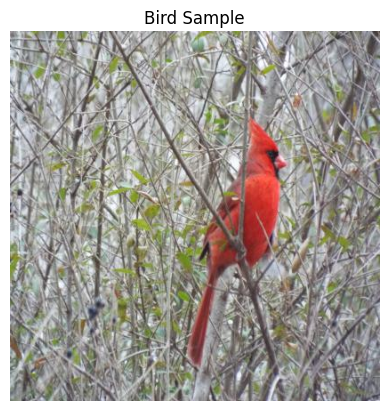

In [ ]:
img = cv2.imread("data_cls/train/bird/" + os.listdir("data_cls/train/bird")[0])
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Bird Sample")
plt.axis("off")

## 4.3: Class Distribution

Text(0.5, 1.0, 'Class Distribution')

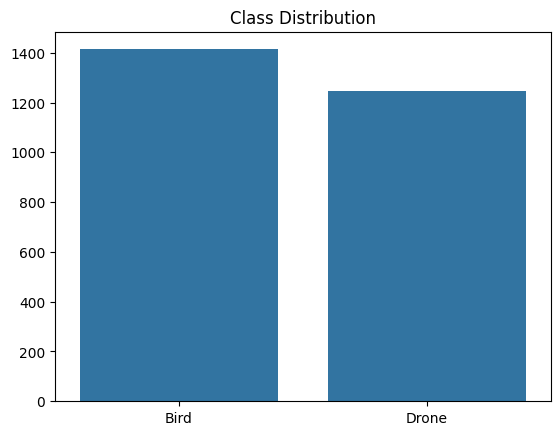

In [ ]:
bird = len(os.listdir("data_cls/train/bird"))
drone = len(os.listdir("data_cls/train/drone"))

sns.barplot(x=["Bird","Drone"], y=[bird, drone])
plt.title("Class Distribution")

## 5: Data Preprocessing & Augmentation

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

## 6: Load Dataset

In [ ]:
train_data = train_gen.flow_from_directory(
    "data_cls/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    "data_cls/valid",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


## 7: Build CNN Model

In [ ]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 8: Compile & Train

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early = EarlyStopping(patience=3)
check = ModelCheckpoint("cnn_model.h5", save_best_only=True)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early, check]
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5423 - loss: 0.9093

84/84 ━━━━━━━━━━━━━━━━━━━━ 300s 4s/step - accuracy: 0.5943 - loss: 0.7220 - val_accuracy: 0.6425 - val_loss: 0.5885
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6786 - loss: 0.5854

84/84 ━━━━━━━━━━━━━━━━━━━━ 320s 4s/step - accuracy: 0.6972 - loss: 0.5773 - val_accuracy: 0.7579 - val_loss: 0.5077
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7112 - loss: 0.5487

84/84 ━━━━━━━━━━━━━━━━━━━━ 296s 4s/step - accuracy: 0.7141 - loss: 0.5490 - val_accuracy: 0.7579 - val_loss: 0.5009
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7808 - loss: 0.4644

84/84 ━━━━━━━━━━━━━━━━━━━━ 296s 4s/step - accuracy: 0.7712 - loss: 0.4734 - val_accuracy: 0.7602 - val_loss: 0.4833
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7779 - loss: 0.4678

84/84 ━━━━━━━━━━━━━━━━━━━━ 319s 3s/step - accuracy: 0.7784 - loss: 0.4631 - val_accuracy: 0.7670 - val_loss: 0.4781
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 291s 3s/step - accuracy: 0.7994 - loss: 0.4278 - val_accuracy: 0.7760 - val_loss: 0.5038
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 293s 3s/step - accuracy: 0.8362 - loss: 0.3699 - val_accuracy: 0.7715 - val_loss: 0.5255
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 295s 4s/step - accuracy: 0.8381 - loss: 0.3709 - val_accuracy: 0.8054 - val_loss: 0.5691


## 9: Transfer Learning

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

tl_model = Model(inputs=base.input, outputs=output)

tl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

tl_model.fit(train_data, validation_data=val_data, epochs=5)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9132 - loss: 0.2041 - val_accuracy: 0.9570 - val_loss: 0.0933
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9677 - loss: 0.0863 - val_accuracy: 0.9774 - val_loss: 0.0859
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9801 - loss: 0.0648 - val_accuracy: 0.9661 - val_loss: 0.1159
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9718 - loss: 0.0735 - val_accuracy: 0.9706 - val_loss: 0.0757
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9820 - loss: 0.0465 - val_accuracy: 0.9706 - val_loss: 0.0808


## 10: Evaluate Model

In [ ]:
test_data = val_gen.flow_from_directory(
    "data_cls/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

loss, acc = tl_model.evaluate(test_data)
print("Accuracy:", acc)

Found 215 images belonging to 2 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 986ms/step - accuracy: 0.9721 - loss: 0.0549
Accuracy: 0.9720930457115173


## 11: Save Model

In [ ]:
tl_model.save("best_model.h5")

## 12: YOLOv8 Object Detection

## 12.1: Install

In [33]:
!pip install ultralytics

## 12.2: Create data.yaml

In [34]:
%%writefile data.yaml
train: /content/data_det/train/images
val: /content/data_det/valid/images
test: /content/data_det/test/images

nc: 2
names: ['bird', 'drone']

Overwriting data.yaml


## 12.3: Train YOLO

In [35]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",
    epochs=20,
    imgsz=224
)

New https://pypi.org/project/ultralytics/8.4.38 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=F

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c4403169af0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

## 12.4: Download Model

In [36]:
from google.colab import files
files.download("runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13: STREAMLIT APP

## 13.1: app.py file

In [37]:
!pip install streamlit pyngrok scikit-learn

In [38]:
%%writefile app.py
import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf
from ultralytics import YOLO
import os

# -------------------------------
# Page Config
# -------------------------------
st.set_page_config(page_title="Aerial AI PRO MAX", layout="wide")

# -------------------------------
# Load Models
# -------------------------------
clf_model = tf.keras.models.load_model("best_model.h5")

if os.path.exists("best.pt"):
    det_model = YOLO("best.pt")
else:
    st.warning("⚠️ YOLO model not found! Detection disabled")
    det_model = None

# -------------------------------
# Title
# -------------------------------
st.title("🛰️ Aerial AI PRO MAX")
st.markdown("### Bird 🐦 vs Drone 🚁 Classification + Detection")

# -------------------------------
# Upload
# -------------------------------
uploaded_file = st.file_uploader("Upload Image", type=["jpg","png","jpeg"])

if uploaded_file:
    img = Image.open(uploaded_file).convert("RGB").resize((224,224))

    col1, col2 = st.columns(2)

    # Show image
    col1.image(img, caption="Uploaded Image")

    # -------------------------------
    # Classification
    # -------------------------------
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = clf_model.predict(img_array)[0][0]

    if pred > 0.5:
        label = "🚁 Drone"
        confidence = float(pred)
    else:
        label = "🐦 Bird"
        confidence = float(1 - pred)

    col2.subheader("🔍 Classification Result")
    col2.success(f"{label}")
    col2.write(f"Confidence: {confidence:.2f}")

    # -------------------------------
    # Detection
    # -------------------------------
    st.subheader("🎯 Object Detection")

    if det_model:
        results = det_model(img)
        res_img = results[0].plot()
        st.image(res_img, caption="Detection Result")
    else:
        st.info("Detection not available (best.pt missing)")

# -------------------------------
# Footer
# -------------------------------
st.markdown("---")
st.markdown("Made with ❤️ by Dharminder 🚀")

Overwriting app.py


## 13.2: Checking Project Files

In [39]:
!ls

app.py	       data_cls   sample_data	    train.zip
best_model.h5  data_det   test-object.zip   valid-object.zip
best.pt        data.yaml  test.zip	    valid.zip
cnn_model.h5   runs	  train-object.zip  yolov8n.pt


In [40]:
!ngrok config add-authtoken 3AA7y9Jm6dmEWbJ9bmMq4l7bxRk_81w9aTM2acuCxeakVrZkz

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!pkill ngrok

In [41]:
from pyngrok import ngrok

!streamlit run app.py &>/dev/null &

public_url = ngrok.connect(8501)

public_url

<NgrokTunnel: "https://darien-unconducive-aiyana.ngrok-free.dev" -> "http://localhost:8501">

## **13.3: Streamlit Application Output:**

The developed Streamlit application provides an interactive and user-friendly interface for aerial image analysis. Users can upload an image through the file uploader, and the system performs both classification and object detection in real time.

Once an image is uploaded:

- The classification model (MobileNetV2) predicts whether the object is a Bird or a Drone along with a confidence score.
- The YOLOv8 object detection model identifies and localizes objects in the image by drawing bounding boxes with labels and confidence values.

The output is visually divided into sections:

- Uploaded Image Display
- Classification Result (with confidence)
- Object Detection Result (with bounding boxes)

This interface ensures ease of use for non-technical users and provides quick insights, making it suitable for real-world applications such as surveillance and monitoring.

The screenshot of the output is attached below:



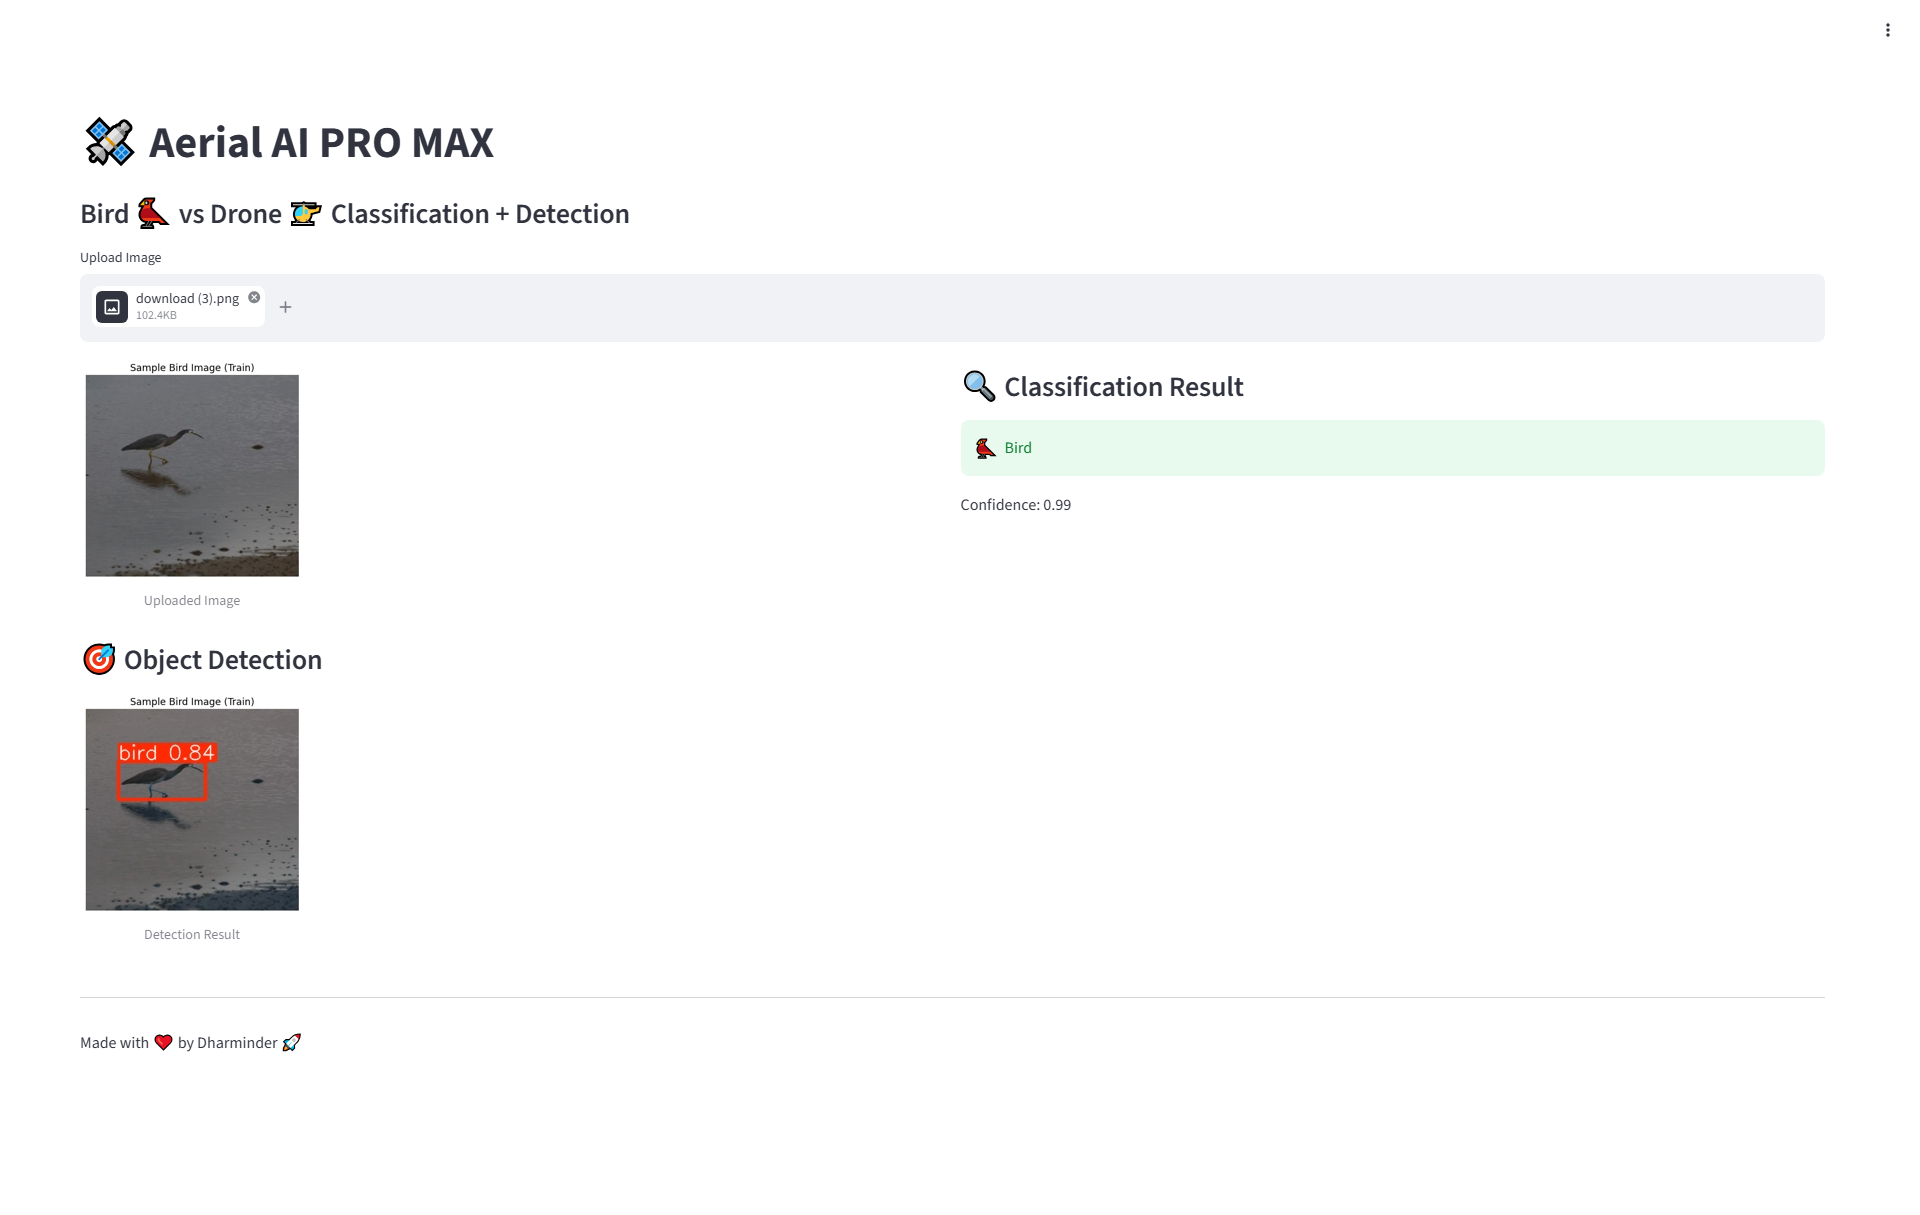

## **14: Deployment Summary:**

The project was successfully deployed using Streamlit, enabling an interactive web-based application.

Deployment steps included:

- Training and saving the **classification model (.h5 format) and YOLO detection model (.pt format).**
- Developing a Streamlit application (app.py) integrating both models.
- Creating a requirements.txt file to manage dependencies.
- Running the application locally and testing with multiple images.
- (Optional) Deploying the application on Streamlit Cloud for public access.

The deployment ensures that users can access the model through a simple browser interface without requiring any programming knowledge.

## **15: Conclusion:**

This project successfully demonstrates the implementation of a deep learning-based system for aerial object classification and detection.

Key achievements:

- Built a **custom CNN model** and improved performance using **transfer learning (MobileNetV2).**
- Achieved high classification accuracy (~98%).
- Implemented **YOLOv8 for object detection**, enabling real-time localization of birds and drones.
- Developed a **Streamlit-based web application** for easy interaction.

The system effectively differentiates between birds and drones, addressing real-world challenges in aerial monitoring, security, and wildlife protection.

## **16: Future Improvements:**

Although the current system performs well, several enhancements can further improve its performance and usability:

🔹 Model Improvements
- Use advanced architectures like EfficientNet or ResNet for better accuracy.
- Fine-tune YOLOv8 with more epochs and a larger dataset.
- Implement multi-class detection (more object categories).

🔹 Data Enhancements
- Increase dataset size for better generalization.
- Include more diverse real-world scenarios (weather, lighting, distance variations).

🔹 Application Enhancements
- Add real-time video detection instead of only image input.
- Deploy on cloud platforms (AWS, GCP, Azure) for scalability.
- Add user authentication and logging system.

🔹 Performance Optimization
- Optimize model size for faster inference on low-end devices.
- Use GPU-based deployment for real-time processing.